# Minggu 2: Model Risiko, CLTV, Segmentasi ML, AI Copywriting
Eksekusi plan dari DETAILEDPLAN.md untuk minggu 2.


In [1]:
# !pip install lifetimes -q


## Hari 1: Scaling dan Baseline Model Isolation Forest


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

# Set style
sns.set_theme(style="whitegrid")


In [3]:
# Load data dari minggu 1
rfm = pd.read_csv('rfm_customer_table.csv', index_col='Customer ID')
rfm.head()


,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RF_Score,Segment,Country
Customer ID,,,,,,,,,
12346.0,326,12,77556.46,2,5,5,25,Can't Loose,United Kingdom
12347.0,2,8,5633.32,5,4,5,54,Champions,Iceland
12348.0,75,5,2019.40,3,4,4,34,Loyal Customers,Finland
12349.0,19,4,4428.69,5,3,5,53,Potential Loyalists,Italy
12350.0,310,1,334.40,2,1,2,21,Hibernating,Norway


In [4]:
# Siapkan fitur untuk Isolation Forest
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
# Uji contamination = 0.05
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

rfm['anomaly_label'] = iso_forest.predict(X_scaled)
# Output decision function (higher values are less anomalous, lower values more anomalous)
rfm['anomaly_score'] = iso_forest.decision_function(X_scaled)

print("Jumlah Anomaly (-1):", (rfm['anomaly_label'] == -1).sum())


Jumlah Anomaly (-1): 294


## Hari 2: Churn Risk Score 0-100


In [5]:
# Konversi anomaly_score ke churn_risk_score (0-100)
# Anomaly score range from roughly -0.5 to 0.5. Lower means more anomalous/risky.
# We will invert it: higher risk score = more anomalous.
min_score = rfm['anomaly_score'].min()
max_score = rfm['anomaly_score'].max()

# Normalisasi 0 sampai 1, tapi invert (1 - terbalik)
rfm['churn_risk_score'] = 100 * (1 - (rfm['anomaly_score'] - min_score) / (max_score - min_score))

# Validasi top 20 high-risk customer
top_risk = rfm.sort_values('churn_risk_score', ascending=False).head(20)
print("Top 20 High-Risk Customers:\n", top_risk[['Recency', 'Frequency', 'Monetary', 'Segment', 'churn_risk_score']])


Top 20 High-Risk Customers:
              Recency  Frequency    Monetary          Segment  churn_risk_score
Customer ID                                                                   
14911.0            1        398  295972.630        Champions        100.000000
14646.0            2        151  528602.520        Champions         98.656775
18102.0            1        145  608821.650        Champions         98.656775
14156.0           10        156  313946.370        Champions         98.535159
13694.0            4        143  196482.810        Champions         98.170803
13089.0            3        203  116737.860        Champions         96.816167
15311.0            1        208  116771.160        Champions         96.455297
15061.0            4        127  137818.520        Champions         95.855472
17850.0          372        155   56600.080      Can't Loose         95.401844
16029.0           39        107  122209.140  Loyal Customers         94.211323
17949.0            1   

## Hari 3: K-Means RFM Segmentation


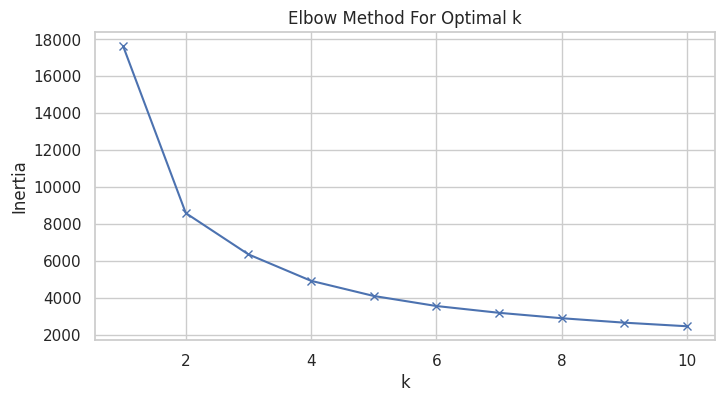

In [6]:
# Transformasi Log untuk K-Means (karena RFM sangat skewed)
def log_transform(x):
    return np.log(x + 1) # avoid log(0)

X_log = X.apply(log_transform)
X_log_scaled = scaler.fit_transform(X_log)

# Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_log_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


In [7]:
# Fit K-Means dengan k=4 (misalnya dari pengamatan elbow)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['KMeansCluster'] = kmeans.fit_predict(X_log_scaled)

# Profiling Cluster
cluster_profile = rfm.groupby('KMeansCluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(cluster_profile)


              Recency Frequency  Monetary      
                 mean      mean      mean count
KMeansCluster                                  
0               27.43     19.34  11014.37  1188
1              395.86      1.38    325.75  1974
2              227.87      5.10   2002.10  1465
3               28.44      3.04    865.11  1251


In [8]:
# Mapping Cluster
# Label secara bisnis berdasarkan centroid (harus disesuaikan dengan hasil di atas)
cluster_map = {
    0: 'High Value',
    1: 'Hibernating',
    2: 'At Risk',
    3: 'New/Ocassional'
}
rfm['KMeansSegment'] = rfm['KMeansCluster'].map(cluster_map)


## Hari 4: CLTV Baseline


In [9]:
# Menggunakan Lifetimes untuk CLTV
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# Kita perlu meload clean_transactions.csv
df_clean = pd.read_csv('clean_transactions.csv', parse_dates=['InvoiceDate'])

# Setup data RFM untuk CLTV (lifetimes format)
# Frequency = repeat purchases, T = customer age, Recency = age at last purchase
cltv_df = summary_data_from_transaction_data(df_clean, 'Customer ID', 'InvoiceDate', monetary_value_col='TotalPrice', observation_period_end=df_clean['InvoiceDate'].max() + dt.timedelta(days=1))

# Filter frequency > 0 (repeat customers only untuk gamma-gamma)
cltv_df = cltv_df[cltv_df['frequency'] > 0]

# Train BG-NBD
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(cltv_df['frequency'], cltv_df['recency'], cltv_df['T'])

# Predict expected purchase in 3 months (90 days)
cltv_df['expected_purc_3_months'] = bgf.conditional_expected_number_of_purchases_up_to_time(90, cltv_df['frequency'], cltv_df['recency'], cltv_df['T'])

# Train Gamma-Gamma
cltv_df = cltv_df[cltv_df['monetary_value'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(cltv_df['frequency'], cltv_df['monetary_value'])

# Predict CLTV (6 months)
cltv_df['cltv_6_months'] = ggf.customer_lifetime_value(
    bgf,
    cltv_df['frequency'],
    cltv_df['recency'],
    cltv_df['T'],
    cltv_df['monetary_value'],
    time=6, # months
    discount_rate=0.01
)

cltv_df['CLTVSegment'] = pd.qcut(cltv_df['cltv_6_months'], 4, labels=['D', 'C', 'B', 'A'])
cltv_df.head()


,frequency,recency,T,monetary_value,expected_purc_3_months,cltv_6_months,CLTVSegment
Customer ID,,,,,,,
12346.0,7.0,400.0,726.0,11066.637143,0.465366,10150.624586,A
12347.0,7.0,402.0,405.0,717.398571,1.471954,2076.853984,A
12348.0,4.0,363.0,439.0,449.310000,0.858751,774.677317,B
12349.0,3.0,571.0,590.0,1120.056667,0.561154,1281.899088,A
12352.0,8.0,356.0,393.0,338.261250,1.666669,1105.889693,A


## Hari 5: Integrasi RFM + Risk + CLTV + Cohort


In [10]:
# Gabung hasil
final_df = rfm.join(cltv_df[['cltv_6_months', 'CLTVSegment']], how='left')
final_df['cltv_6_months'] = final_df['cltv_6_months'].fillna(0)
final_df['CLTVSegment'] = final_df['CLTVSegment'].cat.add_categories('Unknown').fillna('Unknown')

# Prioritas Aksi Marketing
def recommend_action(row):
    if row['CLTVSegment'] in ['A', 'B'] and row['churn_risk_score'] > 75:
        return 'Win-back Priority'
    elif row['CLTVSegment'] in ['A', 'B'] and row['churn_risk_score'] <= 50:
        return 'Loyalty Maintenance'
    elif row['CLTVSegment'] in ['C', 'D'] and row['churn_risk_score'] > 75:
        return 'Low-cost Automation'
    elif row['Segment'] == 'New Customers':
        return 'Onboarding Campaign'
    else:
        return 'Standard Nurture'

final_df['RecommendedAction'] = final_df.apply(recommend_action, axis=1)

final_df.head()


,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RF_Score,Segment,Country,anomaly_label,anomaly_score,churn_risk_score,KMeansCluster,KMeansSegment,cltv_6_months,CLTVSegment,RecommendedAction
Customer ID,,,,,,,,,,,,,,,,,
12346.0,326,12,77556.46,2,5,5,25,Can't Loose,United Kingdom,-1,-0.178270,80.472233,0,High Value,10150.624586,A,Win-back Priority
12347.0,2,8,5633.32,5,4,5,54,Champions,Iceland,1,0.113500,16.851317,0,High Value,2076.853984,A,Loyalty Maintenance
12348.0,75,5,2019.40,3,4,4,34,Loyal Customers,Finland,1,0.170157,4.497094,2,At Risk,774.677317,B,Loyalty Maintenance
12349.0,19,4,4428.69,5,3,5,53,Potential Loyalists,Italy,1,0.121584,15.088455,3,New/Ocassional,1281.899088,A,Loyalty Maintenance
12350.0,310,1,334.40,2,1,2,21,Hibernating,Norway,1,0.155442,7.705682,1,Hibernating,0.000000,Unknown,Standard Nurture


## Hari 7: Evaluasi Minggu 2 dan Paket Demo


In [11]:
final_df.to_csv('enriched_customer_analytics.csv')
print("Saved enriched_customer_analytics.csv")
print("Minggu 2 Selesai!")


Saved enriched_customer_analytics.csv
Minggu 2 Selesai!


--- 1. Evaluasi K-Means Segmentation ---
Silhouette Score for K-Means: 0.365


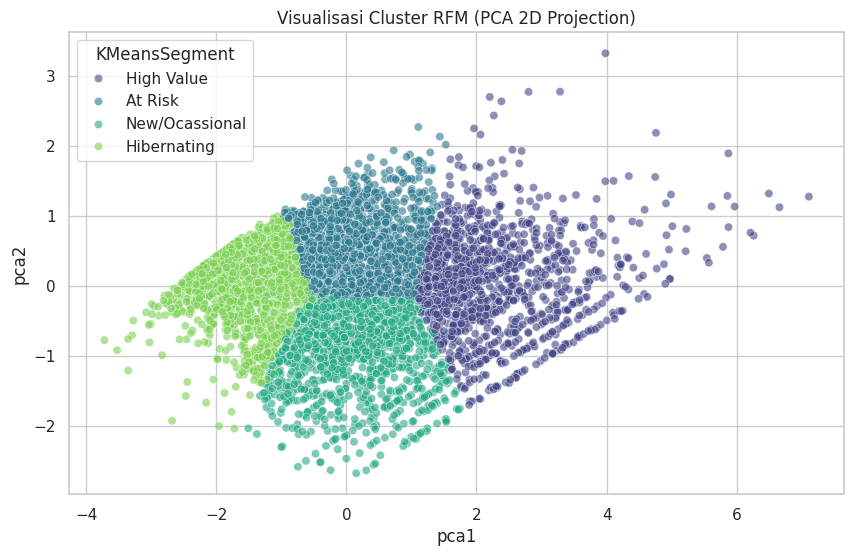

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("--- 1. Evaluasi K-Means Segmentation ---")
# Silhouette Score: Mengukur seberapa baik tiap objek dikelompokkan (Makin dekat 1, makin bagus)
# Skor > 0.25 biasanya dianggap lumayan untuk data retail yang berisik.
sil_score = silhouette_score(X_log_scaled, rfm['KMeansCluster'])
print(f"Silhouette Score for K-Means: {sil_score:.3f}")

# Visualisasi Cluster dengan PCA (2D Projection)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_log_scaled)
rfm['pca1'] = pca_data[:, 0]
rfm['pca2'] = pca_data[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca1', y='pca2', hue='KMeansSegment', data=rfm, palette='viridis', alpha=0.6)
plt.title('Visualisasi Cluster RFM (PCA 2D Projection)')
plt.show()



--- 2. Evaluasi Churn Risk Score (Isolation Forest) ---


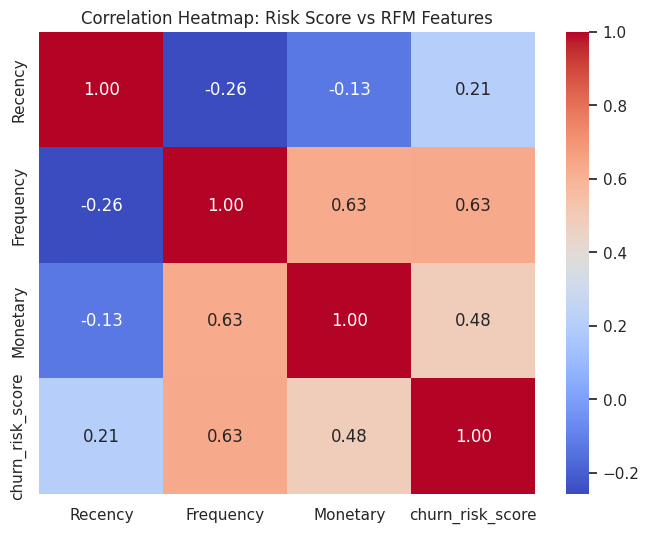

Insight: Jika korelasi Risk Score dengan Recency mendekati 1, berarti model logis.


In [13]:
print("\n--- 2. Evaluasi Churn Risk Score (Isolation Forest) ---")
# Skor risiko harus berkorelasi positif dengan Recency 
# dan mungkin negatif dengan Frequency/Monetary.
correlation = rfm[['Recency', 'Frequency', 'Monetary', 'churn_risk_score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Risk Score vs RFM Features')
plt.show()

print("Insight: Jika korelasi Risk Score dengan Recency mendekati 1, berarti model logis.")



--- 3. Evaluasi Model Probabilistik (CLTV) ---


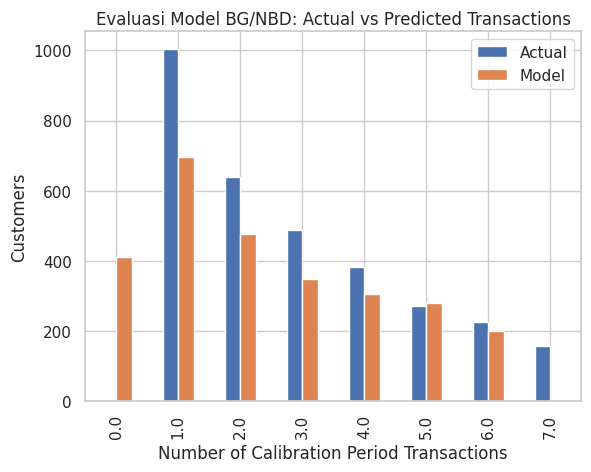

In [14]:
from lifetimes.plotting import plot_period_transactions

print("\n--- 3. Evaluasi Model Probabilistik (CLTV) ---")
# Membandingkan frekuensi transaksi aktual di masa lalu vs prediksi model
plot_period_transactions(bgf)
plt.title('Evaluasi Model BG/NBD: Actual vs Predicted Transactions')
plt.show()


--- Perbandingan Kuantitatif Model ---
       churn_risk_score  churn_risk_lof
count       5878.000000     5878.000000
mean          14.334649        3.178490
std           13.893288        5.051270
min            0.000000        0.000000
25%            5.881511        1.159231
50%            9.733811        1.706860
75%           17.664119        3.013973
max          100.000000      100.000000

Korelasi IF vs Recency: 0.208
Korelasi LOF vs Recency: 0.131

Overlap Top 100 Risky Customers: 32%


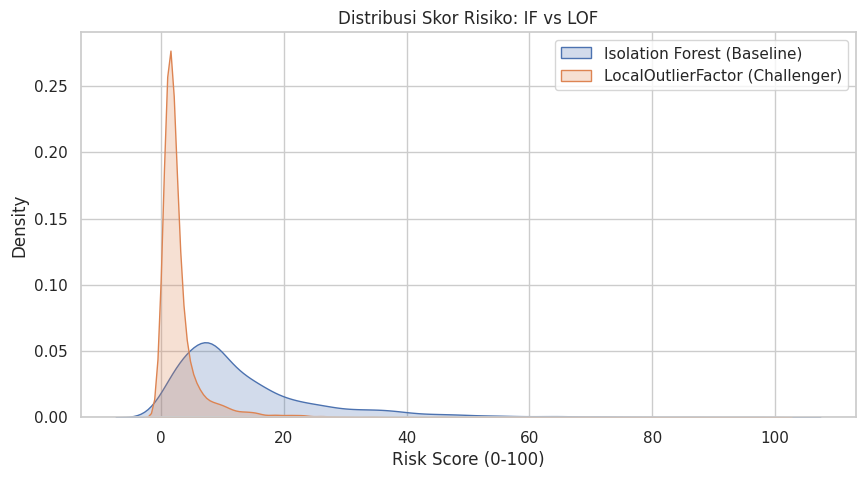

In [16]:
from sklearn.neighbors import LocalOutlierFactor

# 1. Inisialisasi dan Train Model LOF (Challenger)
# novelty=True memungkinkan model untuk melakukan prediksi pada data baru nantinya
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True)
lof.fit(X_scaled)

# Ambil skor anomali (negative_outlier_factor_)
# Semakin rendah nilainya, semakin anomali (berisiko)
rfm['lof_score_raw'] = lof.negative_outlier_factor_

# 2. Normalisasi skor LOF ke skala 0-100 (Inverted: Tinggi = Risiko Tinggi)
min_lof = rfm['lof_score_raw'].min()
max_lof = rfm['lof_score_raw'].max()
rfm['churn_risk_lof'] = 100 * (1 - (rfm['lof_score_raw'] - min_lof) / (max_lof - min_lof))

# 3. Perbandingan Kuantitatif
print("--- Perbandingan Kuantitatif Model ---")

# A. Statistik Deskriptif
comparison_stats = rfm[['churn_risk_score', 'churn_risk_lof']].describe()
print(comparison_stats)

# B. Korelasi dengan Recency (Business Logic Check)
# Model yang lebih baik biasanya memiliki korelasi lebih kuat dengan Recency
corr_if = rfm['churn_risk_score'].corr(rfm['Recency'])
corr_lof = rfm['churn_risk_lof'].corr(rfm['Recency'])

print(f"\nKorelasi IF vs Recency: {corr_if:.3f}")
print(f"Korelasi LOF vs Recency: {corr_lof:.3f}")

# C. Overlap Top 100 Risky Customers
# Menghitung berapa banyak pelanggan yang sama-sama dianggap top-risk oleh kedua model
top_if = set(rfm.sort_values('churn_risk_score', ascending=False).head(100).index)
top_lof = set(rfm.sort_values('churn_risk_lof', ascending=False).head(100).index)
overlap = len(top_if.intersection(top_lof))

print(f"\nOverlap Top 100 Risky Customers: {overlap}%")

# 4. Visualisasi Distribusi Skor
plt.figure(figsize=(10, 5))
sns.kdeplot(rfm['churn_risk_score'], label='Isolation Forest (Baseline)', shade=True)
sns.kdeplot(rfm['churn_risk_lof'], label='LocalOutlierFactor (Challenger)', shade=True)
plt.title('Distribusi Skor Risiko: IF vs LOF')
plt.xlabel('Risk Score (0-100)')
plt.legend()
plt.show()


In [18]:
import joblib
import datetime as dt
import pandas as pd

# 1. Ekstrak hanya parameter penting dari model lifetimes
# Model lifetimes sangat ringan, kita hanya butuh Series 'params_'
bgf_params = bgf.params_
ggf_params = ggf.params_

# 2. Siapkan aset (BGF & GGF disimpan sebagai Series parameter)
deployment_assets = {
    'scaler': scaler,
    'churn_model': iso_forest,
    'segmentation_model': kmeans,
    'cltv_bgf_params': bgf_params,  # Simpan parameternya saja
    'cltv_ggf_params': ggf_params,  # Simpan parameternya saja
    'risk_score_params': {
        'min_score': min_score,
        'max_score': max_score
    },
    'metadata': {
        'export_date': dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'feature_names': features,
        'k_clusters': 4
    }
}

# 3. Export ke file joblib
joblib.dump(deployment_assets, 'retail_ai_model_assets.joblib')

print("Aset model berhasil diekspor (Fix Lifetimes Error): retail_ai_model_assets.joblib")


Aset model berhasil diekspor (Fix Lifetimes Error): retail_ai_model_assets.joblib
